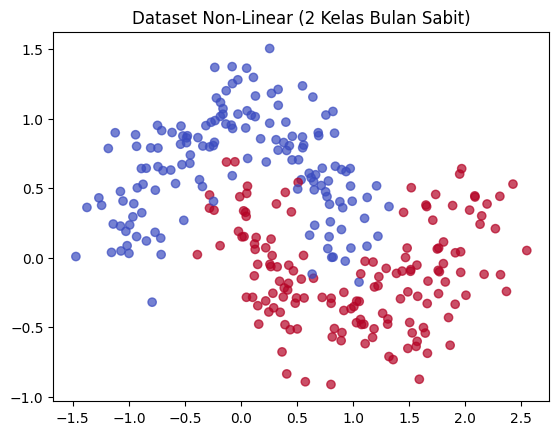

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.show()

In [2]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input # Import Input layer

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

model = Sequential([
    Input(shape=(2,)), # Explicitly define the input layer
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(X_tr, y_tr, epochs=30, validation_split=0.2, verbose=0)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Akurasi pada data uji: 0.900


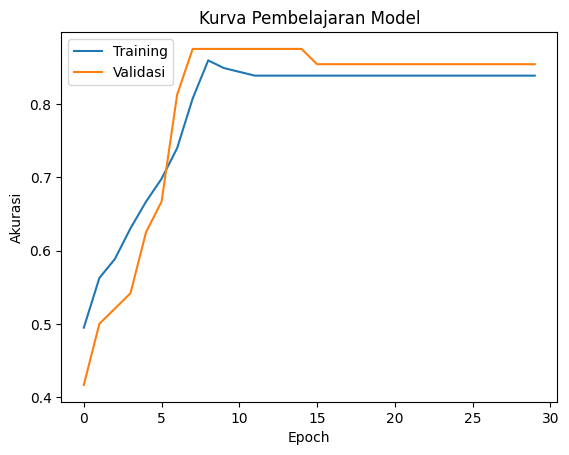

In [3]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')

plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.title('Kurva Pembelajaran Model')
plt.show()


## Analisis Kurva Pembelajaran

**Apakah akurasi training dan validasi saling mendekat atau menjauh?**

Berdasarkan grafik kurva pembelajaran, akurasi pada data **training** dan **validasi** sama-sama meningkat seiring bertambahnya epoch dan terlihat saling mendekat. Selisih akurasi keduanya relatif kecil dan stabil hingga proses pelatihan selesai. Hal ini menunjukkan bahwa model mampu melakukan generalisasi dengan baik dan tidak menunjukkan indikasi **overfitting**, karena performa pada data validasi tetap mengikuti performa data training.

In [4]:
ulasan = [
    'Barangnya bagus banget, pengiriman cepat', 'Kualitas jelek, tidak sesuai deskripsi',
    'Sangat puas, akan beli lagi', 'Kecewa, barang rusak saat sampai',
    'Recommended, harga sesuai kualitas', 'Buruk sekali, tidak sesuai ekspektasi',
    'Pelayanan toko ramah, produk original', 'Sangat mengecewakan, respons penjual lambat',
    'Kainnya halus, jahitan sangat rapi', 'Bahan tipis dan kasar, tidak suka',
    'Fungsi berjalan dengan baik, mantap', 'Barang mati total, tidak bisa menyala',
    'Sesuai dengan foto, pengemasan aman', 'Ukuran salah kirim, tidak pas',
    'Pengiriman kilat, kurir ramah sekali', 'Lama sekali sampainya, kapok belanja di sini',
    'Produk sangat berkualitas premium', 'Harga mahal tapi kualitas abal-abal',
    'Dapat bonus banyak, terima kasih seller', 'Uang terbuang sia-sia, rugi beli ini',
    'Sangat cocok digunakan sehari-hari', 'Desain buruk dan tidak nyaman dipakai',
    'Baterai awet tahan lama, top', 'Boros baterai dan cepat panas',
    'Sangat direkomendasikan untuk dibeli', 'Jangan beli di sini, penipu',
    'Packing tebal pakai bubble wrap', 'Kemasan robek dan hancur berantakan',
    'Suara jernih dan bass mantap', 'Suara cempreng dan rusak sebelah',
    'Warna sesuai pilihan, cantik', 'Warna pudar tidak sesuai gambar',
    'Mudah digunakan dan praktis', 'Sangat ribet penyusunannya, pusing',
    'Fast respon dan pengiriman instan', 'Chat diabaikan berhari-hari oleh toko',
    'Asli puas belanja di toko ini', 'Kapok, kualitas produk sangat mengecewakan',
    'Harga termurah tapi kualitas oke', 'Barang tiruan, bukan original kecewa'
]

label = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
         1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
         1, 0, 1, 0, 1, 0, 1, 0, 1, 0,
         1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

print('Jumlah sampel data ulasan:', len(ulasan))
print('Jumlah sampel data label :', len(label))

Jumlah sampel data ulasan: 40
Jumlah sampel data label : 40


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print('10 Kata unik pertama pada kamus:')
print(tfidf.get_feature_names_out()[:10])

Jumlah kata unik: 137
10 Kata unik pertama pada kamus:
['abal' 'akan' 'aman' 'asli' 'awet' 'bagus' 'bahan' 'baik' 'banget'
 'banyak']


In [6]:
from sklearn.linear_model import LogisticRegression

Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(X_text, label, test_size=0.2, random_state=42)

model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen pada data uji: {akurasi:.3f}')

kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
pred = model_sentimen.predict(tfidf.transform(kalimat_baru))

print(f"Kalimat Baru: '{kalimat_baru[0]}'")
print('Hasil Prediksi Sentimen:', 'Positif' if pred[0] == 1 else 'Negatif')


Akurasi model sentimen pada data uji: 0.375
Kalimat Baru: 'Pelayanan sangat memuaskan dan ramah'
Hasil Prediksi Sentimen: Positif
